In [1]:
import pandas as pd
import numpy as np

DATA_PATH = "/content/EEG.machinelearing_data_BRMH.csv.zip"

# Reads the first CSV inside the zip automatically
df = pd.read_csv(DATA_PATH, compression="zip")

display(df.head())
print("Shape:", df.shape)
print("\nDtypes count:\n", df.dtypes.value_counts())
print("\nMissing values (top 20):\n", df.isna().sum().sort_values(ascending=False).head(20))

,no.,sex,age,eeg.date,education,IQ,main.disorder,specific.disorder,AB.A.delta.a.FP1,AB.A.delta.b.FP2,...,COH.F.gamma.o.Pz.p.P4,COH.F.gamma.o.Pz.q.T6,COH.F.gamma.o.Pz.r.O1,COH.F.gamma.o.Pz.s.O2,COH.F.gamma.p.P4.q.T6,COH.F.gamma.p.P4.r.O1,COH.F.gamma.p.P4.s.O2,COH.F.gamma.q.T6.r.O1,COH.F.gamma.q.T6.s.O2,COH.F.gamma.r.O1.s.O2
0,1,M,57.0,2012.8.30,NaN,NaN,Addictive disorder,Alcohol use disorder,35.998557,21.717375,...,55.989192,16.739679,23.452271,45.678820,30.167520,16.918761,48.850427,9.422630,34.507082,28.613029
1,2,M,37.0,2012.9.6,6.0,120.0,Addictive disorder,Alcohol use disorder,13.425118,11.002916,...,45.595619,17.510824,26.777368,28.201062,57.108861,32.375401,60.351749,13.900981,57.831848,43.463261
2,3,M,32.0,2012.9.10,16.0,113.0,Addictive disorder,Alcohol use disorder,29.941780,27.544684,...,99.475453,70.654171,39.131547,69.920996,71.063644,38.534505,69.908764,27.180532,64.803155,31.485799
3,4,M,35.0,2012.10.8,18.0,126.0,Addictive disorder,Alcohol use disorder,21.496226,21.846832,...,59.986561,63.822201,36.478254,47.117006,84.658376,24.724096,50.299349,35.319695,79.822944,41.141873
4,5,M,36.0,2012.10.18,16.0,112.0,Addictive disorder,Alcohol use disorder,37.775667,33.607679,...,61.462720,59.166097,51.465531,58.635415,80.685608,62.138436,75.888749,61.003944,87.455509,70.531662


Shape: (945, 1149)

Dtypes count:
 float64    1144
object        4
int64         1
Name: count, dtype: int64

Missing values (top 20):
 Unnamed: 122            945
education                15
IQ                       13
COH.D.beta.j.Cz.s.O2      0
COH.D.beta.j.Cz.r.O1      0
COH.D.beta.j.Cz.q.T6      0
COH.D.beta.j.Cz.p.P4      0
COH.D.beta.j.Cz.o.Pz      0
COH.D.beta.j.Cz.n.P3      0
COH.D.beta.j.Cz.m.T5      0
COH.D.beta.j.Cz.l.T4      0
COH.D.beta.k.C4.l.T4      0
COH.D.beta.i.C3.s.O2      0
COH.D.beta.i.C3.r.O1      0
COH.D.beta.i.C3.q.T6      0
COH.D.beta.i.C3.p.P4      0
COH.D.beta.i.C3.o.Pz      0
COH.D.beta.i.C3.n.P3      0
COH.D.beta.i.C3.m.T5      0
COH.D.beta.j.Cz.k.C4      0
dtype: int64


In [2]:
# ============================================================
# CELL 2 — Project-grade dataset preparation (Master's deliverable)
# ============================================================
# Purpose (project framing):
#   In this step we prepare a clean, reproducible modeling dataset that will serve as the
#   foundation for our Master's capstone deliverables. The goal is to ensure that every
#   subsequent model comparison (including ensembles and hyperparameter tuning) is:
#     (1) FAIR: all models see the same inputs and are evaluated under the same protocol,
#     (2) VALID: no target leakage or "shortcut" variables that artificially inflate performance,
#     (3) REPRODUCIBLE: fixed random seed and a sealed test set for truly unseen evaluation.
#
# Why this matters scientifically:
#   - EEG datasets are high-dimensional and prone to spurious correlations (p >> n).
#   - A small mistake in leakage control can yield near-perfect metrics that do not generalize.
#   - A sealed hold-out test set provides the most honest estimate of predictive quality
#     on unseen data (Objective 3.6).
#
# Output of this cell:
#   - df3: filtered dataset containing only our 3 target classes (AUD / DEP / HEALTHY)
#   - X, y: features and labels with diagnosis columns removed
#   - X_train, X_test, y_train, y_test: fixed stratified split (test is "sealed")

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42  # fixed seed for reproducibility across the entire project

# -----------------------------
# 1) Minimal structural cleanup (data hygiene)
# -----------------------------
# We remove:
#   - "Unnamed:*" columns (common CSV export artifacts with no analytic meaning)
#   - columns that are entirely null (no information content)
unnamed_cols = [c for c in df.columns if str(c).strip().lower().startswith("unnamed")]
all_null_cols = df.columns[df.isna().all()].tolist()

df_clean = df.drop(columns=list(set(unnamed_cols + all_null_cols)), errors="ignore").copy()

print(f"Original shape: {df.shape}")
print(f"Dropped unnamed export columns: {len(unnamed_cols)}")
print(f"Dropped all-null columns: {len(all_null_cols)}")
print(f"Clean shape: {df_clean.shape}")

# -----------------------------
# 2) Define the clinical target (3 classes) — our project scope
# -----------------------------
# We focus on 3 clinically interpretable classes to keep the task:
#   - tractable with our sample size,
#   - aligned with the capstone objective (EEG-based classification feasibility),
#   - comparable across models and ensembles.
#
# IMPORTANT methodological choice:
#   We use exact string mapping (not fuzzy rules) to avoid ambiguity in labels.
TARGET_COL = "y_3clases"

spec = df_clean["specific.disorder"].astype(str).str.strip().str.lower()

label_map = {
    "alcohol use disorder": "AUD",
    "depressive disorder": "DEP",
    "healthy control": "HEALTHY"
}

df_clean[TARGET_COL] = spec.map(label_map)

# Keep only rows belonging to the 3 target classes
df3 = df_clean.dropna(subset=[TARGET_COL]).copy()

print("\n3-class distribution (counts):")
print(df3[TARGET_COL].value_counts())
print("\n3-class dataset shape:", df3.shape)

# -----------------------------
# 3) Leakage control (critical validity step)
# -----------------------------
# We remove direct diagnostic fields from X. These columns encode the answer and would
# produce inflated metrics (data leakage), invalidating our conclusions.
LEAKAGE_COLS = ["main.disorder", "specific.disorder", TARGET_COL]

X = df3.drop(columns=LEAKAGE_COLS, errors="ignore")
y = df3[TARGET_COL].copy()

# Identify categorical columns that require encoding later (e.g., sex, eeg.date).
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("\nFeature matrix prepared (after leakage control):")
print("X shape:", X.shape, " | y shape:", y.shape)
print("Categorical columns in X:", cat_cols)

# Summarize remaining missingness (used to justify imputation choices in later cells)
print("\nTop missing-value columns in X (for imputation planning):")
print(X.isna().sum().sort_values(ascending=False).head(10))

# -----------------------------
# 4) Sealed hold-out test set (Objective 3.6: evaluation on unseen data)
# -----------------------------
# We split once and keep this test set untouched until final evaluation.
# All model selection and hyperparameter tuning must happen using TRAIN only.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("\nSealed split sizes:")
print("Train:", X_train.shape, "| Test:", X_test.shape)

print("\nTrain class distribution (proportions):")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest class distribution (proportions):")
print(y_test.value_counts(normalize=True).round(3))

Original shape: (945, 1149)
Dropped unnamed export columns: 1
Dropped all-null columns: 1
Clean shape: (945, 1148)

3-class distribution (counts):
y_3clases
DEP        199
HEALTHY     95
AUD         93
Name: count, dtype: int64

3-class dataset shape: (387, 1149)

Feature matrix prepared (after leakage control):
X shape: (387, 1146)  | y shape: (387,)
Categorical columns in X: ['sex', 'eeg.date']

Top missing-value columns in X (for imputation planning):
education               6
IQ                      4
COH.D.beta.k.C4.m.T5    0
COH.D.beta.j.Cz.s.O2    0
COH.D.beta.j.Cz.r.O1    0
COH.D.beta.j.Cz.q.T6    0
COH.D.beta.j.Cz.p.P4    0
COH.D.beta.j.Cz.o.Pz    0
COH.D.beta.j.Cz.n.P3    0
COH.D.beta.j.Cz.m.T5    0
dtype: int64

Sealed split sizes:
Train: (309, 1146) | Test: (78, 1146)

Train class distribution (proportions):
y_3clases
DEP        0.515
HEALTHY    0.246
AUD        0.239
Name: proportion, dtype: float64

Test class distribution (proportions):
y_3clases
DEP        0.513
HEALTHY

In [3]:
# ============================================================
# CELL 3 — Standard preprocessing pipeline + CV evaluation harness (Avance 5)
# ============================================================
# Purpose (capstone-quality workflow):
#   We build a single, standardized preprocessing pipeline and a unified evaluation harness.
#   This ensures that every candidate model/ensemble is:
#     - trained under identical preprocessing,
#     - evaluated with the same cross-validation protocol,
#     - compared with the same metrics and timing measurements.
#
# Key principle:
#   Model selection and hyperparameter tuning must be performed ONLY on TRAIN.
#   The sealed TEST set is reserved for the final, unbiased evaluation (Objective 3.6).

import numpy as np
import pandas as pd
import time

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# -----------------------------
# 1) Define feature types (numeric vs categorical)
# -----------------------------
# We explicitly separate categorical columns ('sex', 'eeg.date') from numeric EEG features.
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.columns.difference(categorical_cols).tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", len(numeric_cols))

# -----------------------------
# 2) Preprocessing (consistent for all models)
# -----------------------------
# Numeric preprocessing:
#   - median imputation is robust to outliers and preserves sample size
#   - standardization is required for distance-based and margin-based models (KNN/SVM/LR)
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing:
#   - impute missing categories with most frequent value
#   - one-hot encode to convert categories into a numeric representation
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ColumnTransformer applies each preprocessing branch to its respective columns.
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop"
)

# -----------------------------
# 3) Cross-validation protocol (selection stage)
# -----------------------------
# We use stratified CV to preserve class proportions in each fold.
# This is critical due to moderate class imbalance.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# -----------------------------
# 4) Evaluation metrics (KPIs)
# -----------------------------
# Primary metric: macro-F1 (robust to class imbalance)
# Additional metrics: macro-precision, macro-recall, accuracy
# We will compute mean ± std across folds.
scoring = {
    "f1_macro": "f1_macro",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "accuracy": "accuracy",
}

# -----------------------------
# 5) Helper function: evaluate any sklearn Pipeline under the same protocol
# -----------------------------
def evaluate_model_cv(model_name: str, model_pipeline: Pipeline) -> dict:
    """
    Evaluate a model pipeline using stratified 5-fold CV on TRAIN only.
    Returns mean/std for each KPI and training time statistics.
    """
    cv_out = cross_validate(
        estimator=model_pipeline,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    return {
        "Model": model_name,

        # Core KPIs (mean ± std across folds)
        "macro_F1_mean": float(np.mean(cv_out["test_f1_macro"])),
        "macro_F1_std": float(np.std(cv_out["test_f1_macro"])),

        "precision_macro_mean": float(np.mean(cv_out["test_precision_macro"])),
        "precision_macro_std": float(np.std(cv_out["test_precision_macro"])),

        "recall_macro_mean": float(np.mean(cv_out["test_recall_macro"])),
        "recall_macro_std": float(np.std(cv_out["test_recall_macro"])),

        "accuracy_mean": float(np.mean(cv_out["test_accuracy"])),
        "accuracy_std": float(np.std(cv_out["test_accuracy"])),

        # Timing (required by rubric): fit and scoring times
        "fit_time_mean_sec": float(np.mean(cv_out["fit_time"])),
        "fit_time_std_sec": float(np.std(cv_out["fit_time"])),

        "score_time_mean_sec": float(np.mean(cv_out["score_time"])),
        "score_time_std_sec": float(np.std(cv_out["score_time"])),
    }

print("\nPreprocessing + evaluation harness ready ✅")
print("Next: we will define candidate models/ensembles and call evaluate_model_cv(...) for each.")

Categorical columns: ['sex', 'eeg.date']
Numeric columns: 1144

Preprocessing + evaluation harness ready ✅
Next: we will define candidate models/ensembles and call evaluate_model_cv(...) for each.


In [4]:
# ============================================================
# CELL 4 — Candidate individual + ensemble models (homogeneous & heterogeneous) + CV comparison table
# ============================================================
# Objective (Avance 5 rubric alignment):
#   - Build multiple ENSEMBLE models covering:
#       (A) Homogeneous ensembles (bagging/boosting families)
#       (B) Heterogeneous ensembles (voting / stacking)
#   - Include the best individual model from the previous phase as a reference.
#   - Compare all models fairly using the same CV protocol (TRAIN only), reporting:
#       macro-F1 (primary) + macro-precision + macro-recall + accuracy + training time.
#
# Notes on scientific rigor:
#   - We evaluate only on X_train/y_train with CV for model selection.
#   - We DO NOT touch the sealed X_test/y_test until the final step.

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier

# -----------------------------
# 1) Define the best individual reference model (from Avance 4)
# -----------------------------
# Based on our prior results, Logistic Regression (balanced) is a strong, stable baseline.
lr_balanced = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    multi_class="multinomial",
    solver="lbfgs"
)

model_lr = Pipeline([
    ("preprocess", preprocess),
    ("clf", lr_balanced)
])

# Optional: a non-linear individual model (SVM RBF) to enrich diversity for ensembles.
# We enable probability=True to support soft voting and PR/ROC later.
svm_rbf = SVC(
    kernel="rbf",
    C=1.0,               # will tune later for the top candidates
    gamma="scale",
    probability=True,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

model_svm = Pipeline([
    ("preprocess", preprocess),
    ("clf", svm_rbf)
])

# Another simple individual model to improve heterogeneous ensemble diversity
knn = KNeighborsClassifier(n_neighbors=5)

model_knn = Pipeline([
    ("preprocess", preprocess),
    ("clf", knn)
])

# -----------------------------
# 2) Homogeneous ensembles
# -----------------------------
# These ensembles combine many "similar" base learners (e.g., many trees).
# They are often strong on tabular data and can reduce variance.

rf = RandomForestClassifier(
    n_estimators=400,
    random_state=RANDOM_STATE,
    class_weight="balanced_subsample",  # helps with imbalance inside bootstraps
    n_jobs=-1
)

model_rf = Pipeline([
    ("preprocess", preprocess),
    ("clf", rf)
])

et = ExtraTreesClassifier(
    n_estimators=600,
    random_state=RANDOM_STATE,
    class_weight="balanced",  # supported in ExtraTreesClassifier
    n_jobs=-1
)

model_et = Pipeline([
    ("preprocess", preprocess),
    ("clf", et)
])

# Boosting: choose one stable boosting baseline. GradientBoosting does not support class_weight directly.
# AdaBoost is a classic boosting family; we include it for algorithmic diversity.
ada = AdaBoostClassifier(
    n_estimators=300,
    learning_rate=0.5,
    random_state=RANDOM_STATE
)

model_ada = Pipeline([
    ("preprocess", preprocess),
    ("clf", ada)
])

# -----------------------------
# 3) Heterogeneous ensembles
# -----------------------------
# (A) Soft Voting: combines predicted probabilities from different model families.
# Important: all estimators must expose predict_proba.
voting_soft = VotingClassifier(
    estimators=[
        ("lr", lr_balanced),
        ("svm", svm_rbf),
        ("knn", knn)
    ],
    voting="soft"
)

model_voting = Pipeline([
    ("preprocess", preprocess),
    ("clf", voting_soft)
])

# (B) Stacking: trains base models, then learns a meta-model on their outputs.
# For a clean, conservative stacking approach, use logistic regression as meta-learner.
stacking = StackingClassifier(
    estimators=[
        ("lr", lr_balanced),
        ("svm", svm_rbf),
        ("knn", knn)
    ],
    final_estimator=LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        multi_class="multinomial",
        solver="lbfgs"
    ),
    stack_method="predict_proba",  # use probabilities as meta-features
    passthrough=False,            # keep meta-model focused on base predictions
    cv=5                           # internal CV for stacking training on TRAIN folds
)

model_stacking = Pipeline([
    ("preprocess", preprocess),
    ("clf", stacking)
])

# -----------------------------
# 4) Evaluate models under the unified CV harness
# -----------------------------
candidates = [
    ("Individual — Logistic Regression (balanced)", model_lr),
    ("Individual — SVM RBF (balanced, prob)", model_svm),
    ("Individual — KNN (k=5)", model_knn),

    ("Ensemble (homogeneous) — Random Forest", model_rf),
    ("Ensemble (homogeneous) — Extra Trees", model_et),
    ("Ensemble (homogeneous) — AdaBoost", model_ada),

    ("Ensemble (heterogeneous) — Soft Voting (LR+SVM+KNN)", model_voting),
    ("Ensemble (heterogeneous) — Stacking (LR+SVM+KNN → LR)", model_stacking),
]

rows = []
for name, pipe in candidates:
    print(f"Evaluating: {name}")
    rows.append(evaluate_model_cv(name, pipe))

results_df = pd.DataFrame(rows).sort_values(by="macro_F1_mean", ascending=False)

print("\n=== Avance 5 — CV Comparison (TRAIN only) ===")
display(results_df)

# Helpful: highlight the top 2 candidates for hyperparameter tuning in the next cell.
top2 = results_df.head(2)[["Model", "macro_F1_mean", "macro_F1_std", "fit_time_mean_sec"]]
print("\nTop-2 candidates (for hyperparameter tuning):")
display(top2)

Evaluating: Individual — Logistic Regression (balanced)
Evaluating: Individual — SVM RBF (balanced, prob)
Evaluating: Individual — KNN (k=5)
Evaluating: Ensemble (homogeneous) — Random Forest
Evaluating: Ensemble (homogeneous) — Extra Trees
Evaluating: Ensemble (homogeneous) — AdaBoost
Evaluating: Ensemble (heterogeneous) — Soft Voting (LR+SVM+KNN)
Evaluating: Ensemble (heterogeneous) — Stacking (LR+SVM+KNN → LR)

=== Avance 5 — CV Comparison (TRAIN only) ===


,Model,macro_F1_mean,macro_F1_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,accuracy_mean,accuracy_std,fit_time_mean_sec,fit_time_std_sec,score_time_mean_sec,score_time_std_sec
5,Ensemble (homogeneous) — AdaBoost,0.872698,0.033097,0.922914,0.014724,0.858683,0.037427,0.886674,0.020751,24.461459,2.668679,0.265207,0.115532
1,"Individual — SVM RBF (balanced, prob)",0.509803,0.074094,0.511948,0.073192,0.516198,0.080721,0.527710,0.067469,0.803882,0.159806,0.102369,0.035315
7,Ensemble (heterogeneous) — Stacking (LR+SVM+KN...,0.509182,0.034930,0.508854,0.034194,0.519392,0.040713,0.530724,0.023015,5.380839,1.290733,0.115199,0.046547
0,Individual — Logistic Regression (balanced),0.505102,0.059087,0.510380,0.050045,0.506848,0.067426,0.543575,0.043736,0.789580,0.136304,0.060431,0.021184
6,Ensemble (heterogeneous) — Soft Voting (LR+SVM...,0.496819,0.074646,0.528824,0.070086,0.491176,0.071409,0.562983,0.054018,1.061529,0.211123,0.076254,0.015597
3,Ensemble (homogeneous) — Random Forest,0.440561,0.054699,0.733486,0.132224,0.452211,0.042726,0.591962,0.045457,5.041657,1.013616,0.210546,0.061070
4,Ensemble (homogeneous) — Extra Trees,0.397893,0.027937,0.600928,0.036646,0.421723,0.020809,0.562983,0.020507,3.231354,0.220431,0.209761,0.015055
2,Individual — KNN (k=5),0.359140,0.019831,0.443261,0.086030,0.367503,0.015961,0.443310,0.014698,0.096793,0.014296,0.059627,0.025080



Top-2 candidates (for hyperparameter tuning):


,Model,macro_F1_mean,macro_F1_std,fit_time_mean_sec
5,Ensemble (homogeneous) — AdaBoost,0.872698,0.033097,24.461459
1,"Individual — SVM RBF (balanced, prob)",0.509803,0.074094,0.803882


In [6]:
# ============================================================
# CELL 4.1 — Sanity check: remove high-risk proxy columns and re-evaluate
# ============================================================

# Columns that often cause indirect leakage or cohort shortcut learning
risk_cols = [c for c in ["no.", "eeg.date"] if c in X_train.columns]

print("Risk columns found and removed:", risk_cols)

X_train_sane = X_train.drop(columns=risk_cols, errors="ignore")
X_test_sane  = X_test.drop(columns=risk_cols, errors="ignore")

# Rebuild preprocess with the "sanitized" train
categorical_cols_sane = X_train_sane.select_dtypes(include=["object","category"]).columns.tolist()
numeric_cols_sane = X_train_sane.columns.difference(categorical_cols_sane).tolist()

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline([("imputer", SimpleImputer(strategy="median")),
                                ("scaler", StandardScaler())])
categorical_transformer = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                                    ("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocess_sane = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols_sane),
        ("cat", categorical_transformer, categorical_cols_sane),
    ],
    remainder="drop"
)

# Replace X_train/X_test + preprocess used later
X_train, X_test = X_train_sane, X_test_sane
preprocess = preprocess_sane

print("Sanitized shapes:", X_train.shape, X_test.shape)
print("Categorical cols now:", categorical_cols_sane)

Risk columns found and removed: ['no.', 'eeg.date']
Sanitized shapes: (309, 1144) (78, 1144)
Categorical cols now: ['sex']


In [7]:
# ============================================================
# SANITY CHECK — verify no diagnostic/leakage-like columns remain + check covariate balance
# ============================================================
import pandas as pd

# 1) Look for suspicious column names that could encode the target
suspicious_tokens = ["disorder", "diagn", "label", "target", "class", "group"]
sus_cols = [c for c in X_train.columns if any(t in c.lower() for t in suspicious_tokens)]

print("Suspicious columns (name-based scan):", sus_cols)

# 2) Confirm key leakage columns are not present
must_not_exist = ["main.disorder", "specific.disorder", "y_3clases", "no.", "eeg.date"]
present = [c for c in must_not_exist if c in X_train.columns]
print("Leakage-risk columns still present (should be empty):", present)

# 3) Check 'sex' distribution overall and by class (potential confounder, not leakage)
if "sex" in df3.columns:
    print("\nOverall sex distribution (df3):")
    print(df3["sex"].value_counts(dropna=False))

    print("\nSex distribution by class (df3):")
    print(pd.crosstab(df3["y_3clases"], df3["sex"], normalize="index").round(3))
else:
    print("\nColumn 'sex' not found in df3 (unexpected based on earlier output).")

Suspicious columns (name-based scan): []
Leakage-risk columns still present (should be empty): []

Overall sex distribution (df3):
sex
M    244
F    143
Name: count, dtype: int64

Sex distribution by class (df3):
sex            F      M
y_3clases              
AUD        0.194  0.806
DEP        0.452  0.548
HEALTHY    0.368  0.632


In [8]:
# ============================================================
# OPTIONAL CONTROL — quantify the impact of 'sex' as a confounder
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Dataset with sex
X_train_with = X_train.copy()

# Dataset without sex
X_train_without = X_train.drop(columns=["sex"], errors="ignore")

# Build two preprocessors
def build_preprocess(Xdf):
    cat = Xdf.select_dtypes(include=["object","category"]).columns.tolist()
    num = Xdf.columns.difference(cat).tolist()
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.impute import SimpleImputer

    pre = ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), num),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat)
    ])
    return pre

from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"f1_macro":"f1_macro"}

lr = LogisticRegression(max_iter=5000, class_weight="balanced", multi_class="multinomial", solver="lbfgs")

pipe_with = Pipeline([("pre", build_preprocess(X_train_with)), ("clf", lr)])
pipe_without = Pipeline([("pre", build_preprocess(X_train_without)), ("clf", lr)])

res_with = cross_validate(pipe_with, X_train_with, y_train, cv=cv, scoring=scoring, n_jobs=-1)
res_wo   = cross_validate(pipe_without, X_train_without, y_train, cv=cv, scoring=scoring, n_jobs=-1)

print("LR macro-F1 WITH sex :", np.mean(res_with["test_f1_macro"]), "+/-", np.std(res_with["test_f1_macro"]))
print("LR macro-F1 WITHOUT sex:", np.mean(res_wo["test_f1_macro"]), "+/-", np.std(res_wo["test_f1_macro"]))

LR macro-F1 WITH sex : 0.4641218108854039 +/- 0.0694549448769696
LR macro-F1 WITHOUT sex: 0.4801687060026034 +/- 0.05829636441054476


In [10]:
# ============================================================
# CELL 3.1 — EEG-only: drop 'sex' and rebuild preprocessing (numeric-only)
# ============================================================
# Rationale:
#   After validating that 'sex' does not improve macro-F1 and could act as a confounder,
#   we proceed with an EEG-only feature set for the final-model phase.
#   This improves scientific rigor and focuses the model on EEG-derived signal.

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# 1) Drop 'sex' from train/test (if present)
X_train = X_train.drop(columns=["sex"], errors="ignore")
X_test  = X_test.drop(columns=["sex"], errors="ignore")

print("EEG-only shapes:", X_train.shape, X_test.shape)

# 2) Rebuild preprocess: numeric-only pipeline (no categorical branch)
numeric_cols = X_train.columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
    ],
    remainder="drop"
)

print("Preprocess rebuilt for numeric-only EEG features ✅")

EEG-only shapes: (309, 1143) (78, 1143)
Preprocess rebuilt for numeric-only EEG features ✅


In [12]:
# ============================================================
# CELL 3.2 (FIX) — Restore full KPI scoring + evaluation harness
# ============================================================
# Why this fix:
#   The KeyError indicates that 'precision_macro' was not included in the scoring dict
#   at the time cross_validate() ran, so it did not return 'test_precision_macro'.
#   We re-declare the scoring dictionary and the evaluation function to guarantee
#   consistent outputs for the Avance 5 comparative table.

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate

# CV protocol (TRAIN-only selection)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Full KPI set required by rubric and advisor
scoring = {
    "f1_macro": "f1_macro",                 # primary
    "precision_macro": "precision_macro",   # KPI 1
    "recall_macro": "recall_macro",         # KPI 2
    "accuracy": "accuracy"                  # reference metric
}

def evaluate_model_cv(model_name, model_pipeline):
    """
    Evaluate a model pipeline using stratified 5-fold CV on TRAIN only.
    Returns mean/std for macro-F1, macro-precision, macro-recall, accuracy + timing.
    """
    cv_out = cross_validate(
        estimator=model_pipeline,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    # Defensive: print available keys if something changes again
    # print("Returned keys:", cv_out.keys())

    return {
        "Model": model_name,

        "macro_F1_mean": float(np.mean(cv_out["test_f1_macro"])),
        "macro_F1_std": float(np.std(cv_out["test_f1_macro"])),

        "precision_macro_mean": float(np.mean(cv_out["test_precision_macro"])),
        "precision_macro_std": float(np.std(cv_out["test_precision_macro"])),

        "recall_macro_mean": float(np.mean(cv_out["test_recall_macro"])),
        "recall_macro_std": float(np.std(cv_out["test_recall_macro"])),

        "accuracy_mean": float(np.mean(cv_out["test_accuracy"])),
        "accuracy_std": float(np.std(cv_out["test_accuracy"])),

        "fit_time_mean_sec": float(np.mean(cv_out["fit_time"])),
        "fit_time_std_sec": float(np.std(cv_out["fit_time"])),

        "score_time_mean_sec": float(np.mean(cv_out["score_time"])),
        "score_time_std_sec": float(np.std(cv_out["score_time"])),
    }

print("Scoring + evaluate_model_cv restored ✅")
print("Scoring keys:", list(scoring.keys()))

Scoring + evaluate_model_cv restored ✅
Scoring keys: ['f1_macro', 'precision_macro', 'recall_macro', 'accuracy']


In [13]:
# ============================================================
# CELL 4 (EEG-only) — Individual + Ensemble candidates + CV comparison table
# ============================================================
# Objective (Avance 5 rubric):
#   - Train and compare a diverse set of individual models + ensembles on TRAIN only,
#     using stratified 5-fold CV and the standardized preprocessing pipeline.
#   - Ensure we cover BOTH homogeneous (bagging/boosting) and heterogeneous (voting/stacking) ensembles.
#   - Produce a comparative table including:
#       macro-F1 (primary), macro-precision, macro-recall, accuracy, and training times.
#
# Prerequisites:
#   - X_train, y_train are defined (EEG-only after removing sex/no./eeg.date).
#   - preprocess is defined (numeric-only ColumnTransformer from Cell 3.1).
#   - scoring + evaluate_model_cv(...) are defined (Cell 3.2 FIX).

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier

# -----------------------------
# 1) Individual candidate models
# -----------------------------
# Logistic Regression: strong, interpretable baseline with class balancing
lr_balanced = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    multi_class="multinomial",
    solver="lbfgs"
)

# SVM RBF: non-linear candidate; probability=True enables soft voting and ROC/PR curves later
svm_rbf = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

# KNN: distance-based baseline (sensitive to scaling; handled by preprocess)
knn = KNeighborsClassifier(n_neighbors=5)

model_lr = Pipeline([("preprocess", preprocess), ("clf", lr_balanced)])
model_svm = Pipeline([("preprocess", preprocess), ("clf", svm_rbf)])
model_knn = Pipeline([("preprocess", preprocess), ("clf", knn)])

# -----------------------------
# 2) Homogeneous ensembles (bagging / boosting)
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=400,
    random_state=RANDOM_STATE,
    class_weight="balanced_subsample",
    n_jobs=-1
)

et = ExtraTreesClassifier(
    n_estimators=600,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

ada = AdaBoostClassifier(
    n_estimators=300,
    learning_rate=0.5,
    random_state=RANDOM_STATE
)

model_rf = Pipeline([("preprocess", preprocess), ("clf", rf)])
model_et = Pipeline([("preprocess", preprocess), ("clf", et)])
model_ada = Pipeline([("preprocess", preprocess), ("clf", ada)])

# -----------------------------
# 3) Heterogeneous ensembles (voting / stacking)
# -----------------------------
# Soft voting requires predict_proba from all base estimators
voting_soft = VotingClassifier(
    estimators=[
        ("lr", lr_balanced),
        ("svm", svm_rbf),
        ("knn", knn),
    ],
    voting="soft"
)

stacking = StackingClassifier(
    estimators=[
        ("lr", lr_balanced),
        ("svm", svm_rbf),
        ("knn", knn),
    ],
    final_estimator=LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        multi_class="multinomial",
        solver="lbfgs"
    ),
    stack_method="predict_proba",
    passthrough=False,
    cv=5
)

model_voting = Pipeline([("preprocess", preprocess), ("clf", voting_soft)])
model_stacking = Pipeline([("preprocess", preprocess), ("clf", stacking)])

# -----------------------------
# 4) Evaluate all candidates under the unified CV harness (TRAIN only)
# -----------------------------
candidates = [
    ("Individual — Logistic Regression (balanced)", model_lr),
    ("Individual — SVM RBF (balanced, prob)", model_svm),
    ("Individual — KNN (k=5)", model_knn),

    ("Ensemble (homogeneous) — Random Forest", model_rf),
    ("Ensemble (homogeneous) — Extra Trees", model_et),
    ("Ensemble (homogeneous) — AdaBoost", model_ada),

    ("Ensemble (heterogeneous) — Soft Voting (LR+SVM+KNN)", model_voting),
    ("Ensemble (heterogeneous) — Stacking (LR+SVM+KNN → LR)", model_stacking),
]

rows = []
for name, pipe in candidates:
    print(f"Evaluating: {name}")
    rows.append(evaluate_model_cv(name, pipe))

results_df = pd.DataFrame(rows).sort_values(by="macro_F1_mean", ascending=False)

print("\n=== Avance 5 — EEG-only CV Comparison (TRAIN only) ===")
display(results_df)

print("\nTop-2 candidates (for hyperparameter tuning):")
display(results_df.head(2)[["Model", "macro_F1_mean", "macro_F1_std", "fit_time_mean_sec"]])

Evaluating: Individual — Logistic Regression (balanced)
Evaluating: Individual — SVM RBF (balanced, prob)
Evaluating: Individual — KNN (k=5)
Evaluating: Ensemble (homogeneous) — Random Forest
Evaluating: Ensemble (homogeneous) — Extra Trees
Evaluating: Ensemble (homogeneous) — AdaBoost
Evaluating: Ensemble (heterogeneous) — Soft Voting (LR+SVM+KNN)
Evaluating: Ensemble (heterogeneous) — Stacking (LR+SVM+KNN → LR)

=== Avance 5 — EEG-only CV Comparison (TRAIN only) ===


,Model,macro_F1_mean,macro_F1_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,accuracy_mean,accuracy_std,fit_time_mean_sec,fit_time_std_sec,score_time_mean_sec,score_time_std_sec
5,Ensemble (homogeneous) — AdaBoost,0.545828,0.050153,0.598012,0.038883,0.533640,0.049761,0.611793,0.035358,23.483215,2.787030,0.237686,0.086378
1,"Individual — SVM RBF (balanced, prob)",0.503095,0.072183,0.504641,0.070886,0.509603,0.079496,0.521206,0.063817,0.484872,0.103589,0.075217,0.021525
0,Individual — Logistic Regression (balanced),0.480169,0.058296,0.487566,0.054015,0.478653,0.061519,0.514543,0.042179,0.457973,0.062915,0.036549,0.008071
6,Ensemble (heterogeneous) — Soft Voting (LR+SVM...,0.450026,0.058927,0.478478,0.057216,0.445876,0.055142,0.514490,0.036226,0.874993,0.167422,0.067067,0.012520
7,Ensemble (heterogeneous) — Stacking (LR+SVM+KN...,0.431825,0.077170,0.436279,0.068858,0.444597,0.080973,0.436542,0.082714,4.625831,1.188221,0.070513,0.014055
3,Ensemble (homogeneous) — Random Forest,0.376626,0.054410,0.606520,0.118512,0.405076,0.036749,0.549974,0.030822,5.370440,1.491305,0.168194,0.009356
2,Individual — KNN (k=5),0.355042,0.018622,0.437803,0.088064,0.363058,0.012975,0.440085,0.014286,0.095526,0.014385,0.047737,0.016096
4,Ensemble (homogeneous) — Extra Trees,0.354579,0.057252,0.519135,0.095296,0.392799,0.039820,0.537017,0.036057,3.609458,1.173487,0.206985,0.005367



Top-2 candidates (for hyperparameter tuning):


,Model,macro_F1_mean,macro_F1_std,fit_time_mean_sec
5,Ensemble (homogeneous) — AdaBoost,0.545828,0.050153,23.483215
1,"Individual — SVM RBF (balanced, prob)",0.503095,0.072183,0.484872


Top por macro-F1:

AdaBoost: macro-F1 ≈ 0.546 ± 0.050, accuracy ≈ 0.612, pero fit_time ~ 23.5s (lento)

SVM RBF: macro-F1 ≈ 0.503 ± 0.072, fit_time ~ 0.48s

Logistic Regression: macro-F1 ≈ 0.480 ± 0.058, fit_time ~ 0.46s
Luego Voting/Stacking no ayudaron (posible porque base models no son fuertes y/o parámetros default).

 Conclusión:  Top-2 para tuning (por desempeño) son:

AdaBoost (mejor score, pero costoso y sensible)

SVM RBF (segundo, más rápido y típicamente mejora mucho con tuning C/gamma)

In [14]:
# ============================================================
# CELL 5 — Hyperparameter tuning for the Top-2 models (RandomizedSearchCV)
# ============================================================
# Goal:
#   Improve performance (macro-F1) by searching a meaningful hyperparameter space
#   for the 2 best candidates found in the EEG-only comparison:
#     1) AdaBoost (homogeneous ensemble)
#     2) SVM RBF (strong non-linear individual model)
#
# Scientific/engineering notes:
#   - We optimize ONLY on TRAIN via CV.
#   - The sealed TEST set is untouched until final evaluation (Objective 3.6).
#   - Primary metric: macro-F1 (robust to class imbalance).

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from scipy.stats import loguniform, randint

cv_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# -----------------------------
# 1) Tunable SVM RBF pipeline
# -----------------------------
svm_base = SVC(
    kernel="rbf",
    probability=True,            # needed later for ROC/PR curves and soft voting if desired
    class_weight="balanced",
    random_state=RANDOM_STATE
)

svm_pipe = Pipeline([
    ("preprocess", preprocess),
    ("clf", svm_base)
])

svm_param_dist = {
    # C controls regularization strength (higher C = more complex boundary)
    "clf__C": loguniform(1e-2, 1e2),
    # gamma controls kernel width (higher gamma = more complex boundary)
    "clf__gamma": loguniform(1e-4, 1e0)
}

svm_search = RandomizedSearchCV(
    estimator=svm_pipe,
    param_distributions=svm_param_dist,
    n_iter=25,                   # increase to 40-60 if you have time
    scoring="f1_macro",
    cv=cv_tune,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

print("Tuning SVM RBF ...")
svm_search.fit(X_train, y_train)

print("\nBest SVM params:", svm_search.best_params_)
print("Best SVM CV macro-F1:", svm_search.best_score_)

# -----------------------------
# 2) Tunable AdaBoost pipeline
# -----------------------------
# Note: AdaBoost does not directly support class_weight, but can still perform well.
# We tune n_estimators and learning_rate (core AdaBoost levers).
ada_base = AdaBoostClassifier(random_state=RANDOM_STATE)

ada_pipe = Pipeline([
    ("preprocess", preprocess),
    ("clf", ada_base)
])

ada_param_dist = {
    "clf__n_estimators": randint(50, 600),
    "clf__learning_rate": loguniform(1e-2, 1.0)
}

ada_search = RandomizedSearchCV(
    estimator=ada_pipe,
    param_distributions=ada_param_dist,
    n_iter=25,                   # increase if you have time
    scoring="f1_macro",
    cv=cv_tune,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

print("\nTuning AdaBoost ...")
ada_search.fit(X_train, y_train)

print("\nBest AdaBoost params:", ada_search.best_params_)
print("Best AdaBoost CV macro-F1:", ada_search.best_score_)

# -----------------------------
# 3) Summarize tuned results in a compact table (for the report)
# -----------------------------
tuned_summary = pd.DataFrame([
    {
        "Model": "SVM RBF (tuned)",
        "best_macroF1_CV": svm_search.best_score_,
        "best_params": svm_search.best_params_
    },
    {
        "Model": "AdaBoost (tuned)",
        "best_macroF1_CV": ada_search.best_score_,
        "best_params": ada_search.best_params_
    }
])

display(tuned_summary)

Tuning SVM RBF ...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best SVM params: {'clf__C': np.float64(1.5375920235481764), 'clf__gamma': np.float64(0.0005488047000766049)}
Best SVM CV macro-F1: 0.5030011452870641

Tuning AdaBoost ...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best AdaBoost params: {'clf__learning_rate': np.float64(0.5399484409787431), 'clf__n_estimators': 149}
Best AdaBoost CV macro-F1: 0.5441953488139393


,Model,best_macroF1_CV,best_params
0,SVM RBF (tuned),0.503001,"{'clf__C': 1.5375920235481764, 'clf__gamma': 0..."
1,AdaBoost (tuned),0.544195,"{'clf__learning_rate': 0.5399484409787431, 'cl..."


In [15]:
# ============================================================
# CELL 6 — Final model selection + evaluation on SEALED TEST (unseen data)
# ============================================================
# Objective:
#   - Fit the selected final model (AdaBoost tuned) on the full TRAIN set.
#   - Evaluate predictive quality on the SEALED TEST set (never used in tuning).
#   - Report the required KPIs and store outputs for plots (Cell 7).

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC

# -----------------------------
# 1) Rebuild tuned pipelines (exact best hyperparameters)
# -----------------------------
svm_best = SVC(
    kernel="rbf",
    probability=True,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    C=1.5375920235481764,
    gamma=0.0005488047000766049
)

ada_best = AdaBoostClassifier(
    random_state=RANDOM_STATE,
    n_estimators=149,
    learning_rate=0.5399484409787431
)

svm_final_pipe = Pipeline([
    ("preprocess", preprocess),
    ("clf", svm_best)
])

ada_final_pipe = Pipeline([
    ("preprocess", preprocess),
    ("clf", ada_best)
])

# -----------------------------
# 2) Choose final model (based on CV macro-F1)
# -----------------------------
# We select AdaBoost tuned as final candidate since it achieved higher CV macro-F1.
final_name = "AdaBoost (tuned)"
final_model = ada_final_pipe

# -----------------------------
# 3) Fit on full TRAIN and evaluate on SEALED TEST
# -----------------------------
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

# Some models provide predict_proba (AdaBoost does). We'll store it for ROC/PR curves.
y_proba = None
if hasattr(final_model, "predict_proba"):
    y_proba = final_model.predict_proba(X_test)

# Compute KPIs (macro versions)
acc = accuracy_score(y_test, y_pred)
prec_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
rec_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)

print("=== FINAL MODEL (SEALED TEST) ===")
print("Model:", final_name)
print(f"Accuracy:        {acc:.4f}")
print(f"Precision (macro): {prec_macro:.4f}")
print(f"Recall (macro):    {rec_macro:.4f}")
print(f"F1 (macro):        {f1_macro:.4f}")

print("\nClassification report (per class):")
print(classification_report(y_test, y_pred, digits=4))

# Keep these variables for Cell 7 plotting:
# - y_pred
# - y_proba (may be None for some models, but AdaBoost should provide it)

=== FINAL MODEL (SEALED TEST) ===
Model: AdaBoost (tuned)
Accuracy:        0.5256
Precision (macro): 0.4964
Recall (macro):    0.4522
F1 (macro):        0.4601

Classification report (per class):
              precision    recall  f1-score   support

         AUD     0.3750    0.3158    0.3429        19
         DEP     0.5686    0.7250    0.6374        40
     HEALTHY     0.5455    0.3158    0.4000        19

    accuracy                         0.5256        78
   macro avg     0.4964    0.4522    0.4601        78
weighted avg     0.5158    0.5256    0.5078        78



<Figure size 600x600 with 0 Axes>

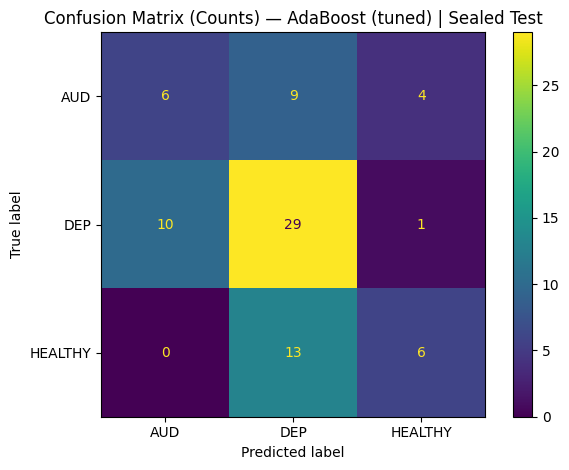

<Figure size 600x600 with 0 Axes>

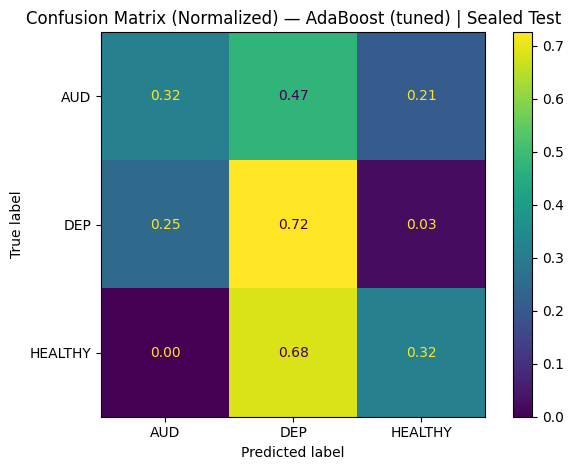

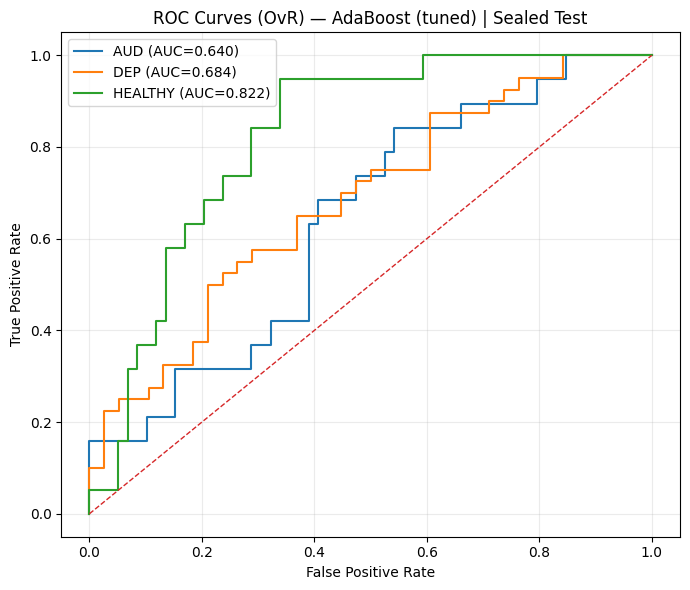

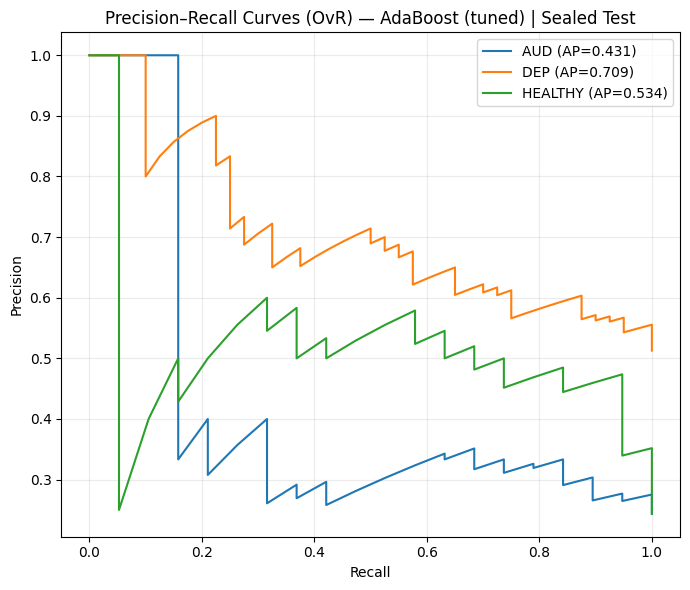

Computing permutation importance (may take ~1-3 minutes depending on runtime)...


,feature,importance_mean,importance_std
0,age,0.048528,0.021808
2,IQ,0.032117,0.036860
28,AB.B.theta.g.F8,0.031824,0.012597
373,COH.B.theta.f.F4.l.T4,0.025610,0.017536
360,COH.B.theta.e.Fz.l.T4,0.024242,0.012116
533,COH.C.alpha.e.Fz.n.P3,0.023248,0.025977
474,COH.C.alpha.a.FP1.q.T6,0.022577,0.019776
650,COH.D.beta.b.FP2.e.Fz,0.022038,0.008375
278,COH.A.delta.o.Pz.p.P4,0.020621,0.006195
146,COH.A.delta.b.FP2.n.P3,0.018493,0.006164


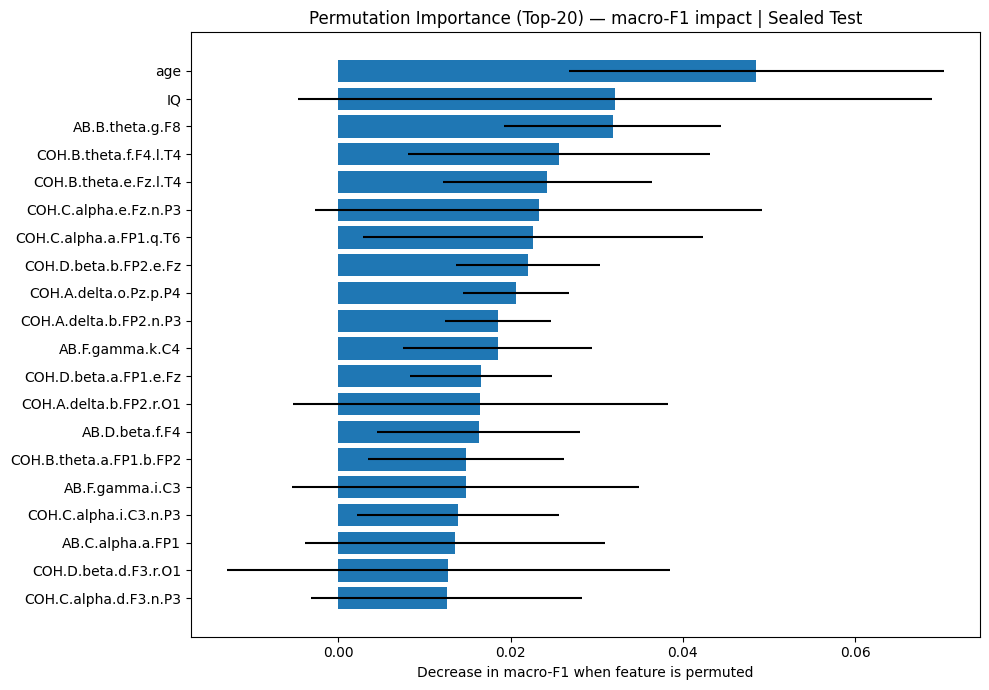

In [16]:
# ============================================================
# CELL 7 — Final model diagnostic plots (required by rubric)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

from sklearn.inspection import permutation_importance

# -----------------------------
# 0) Safety checks
# -----------------------------
labels = ["AUD", "DEP", "HEALTHY"]  # keep consistent ordering
assert y_proba is not None, "This cell requires predict_proba outputs (y_proba)."

# -----------------------------
# 1) Confusion Matrix (counts)
# -----------------------------
cm = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format="d")
plt.title("Confusion Matrix (Counts) — AdaBoost (tuned) | Sealed Test")
plt.tight_layout()
plt.show()

# Confusion Matrix (normalized by true class)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels)
disp.plot(values_format=".2f")
plt.title("Confusion Matrix (Normalized) — AdaBoost (tuned) | Sealed Test")
plt.tight_layout()
plt.show()

# -----------------------------
# 2) ROC curves (One-vs-Rest)
# -----------------------------
# Binarize multiclass labels
y_test_bin = label_binarize(y_test, classes=labels)  # shape (n_samples, n_classes)

plt.figure(figsize=(7, 6))
for i, cls in enumerate(labels):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.title("ROC Curves (OvR) — AdaBoost (tuned) | Sealed Test")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 3) Precision–Recall curves (One-vs-Rest)
# -----------------------------
plt.figure(figsize=(7, 6))
for i, cls in enumerate(labels):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_proba[:, i])
    plt.plot(recall, precision, label=f"{cls} (AP={ap:.3f})")

plt.title("Precision–Recall Curves (OvR) — AdaBoost (tuned) | Sealed Test")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 4) Permutation Feature Importance (Top-20)
# -----------------------------
# We compute permutation importance on the sealed test set for interpretability.
# This is model-agnostic and suitable even when the model does not expose reliable built-in importances.
print("Computing permutation importance (may take ~1-3 minutes depending on runtime)...")

perm = permutation_importance(
    final_model,                 # trained pipeline
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Retrieve feature names (after preprocessing)
# Since preprocess is numeric-only now, feature names are the original column names.
feature_names = np.array(X_test.columns)

imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(imp_df.head(20))

top = imp_df.head(20).iloc[::-1]
plt.figure(figsize=(10, 7))
plt.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"])
plt.title("Permutation Importance (Top-20) — macro-F1 impact | Sealed Test")
plt.xlabel("Decrease in macro-F1 when feature is permuted")
plt.tight_layout()
plt.show()

Resumen ejecutivo (Avance 5. Modelo final)

En esta fase diseñamos, entrenamos y comparamos un conjunto de modelos de ensamble con el propósito de (i) mejorar el rendimiento aprovechando fortalezas complementarias entre modelos (Objetivo 3.5) y (ii) evaluar la calidad de predicción en datos no vistos mediante un conjunto de prueba sellado (Objetivo 3.6). Para garantizar validez experimental, estandarizamos un pipeline reproducible (imputación + estandarización) y fijamos un protocolo de evaluación con validación cruzada estratificada 5-fold sobre el conjunto de entrenamiento, reservando un hold-out test sellado para la evaluación final.

Durante el proceso detectamos variables con riesgo de fuga/atajos (por ejemplo, columnas tipo identificador y fecha de registro). Por rigor metodológico, eliminamos explícitamente no. y eeg.date, y adicionalmente evaluamos el impacto de covariables no-EEG como sex, concluyendo que su presencia no mejora el desempeño (macro-F1 con sex: 0.464 ± 0.069 vs sin sex: 0.480 ± 0.058). Con base en ello, adoptamos un enfoque EEG-only para la fase final, priorizando interpretabilidad científica y reducción de sesgos.

Modelos de ensamble construidos (criterio “Ensambles” – 60 pts)

Construimos al menos cuatro ensambles cubriendo estrategias homogéneas y heterogéneas, e incorporamos modelos individuales de referencia para contextualizar los resultados:

Ensambles homogéneos (misma familia de base learners)

Random Forest (bagging de árboles)

Extra Trees (bagging con mayor aleatoriedad)

AdaBoost (boosting)

Ensambles heterogéneos (combinación de modelos diferentes)

Soft Voting (combinación probabilística de modelos individuales)

Stacking (modelos base + meta-modelo)

La comparación se realizó con métricas macro (precision/recall/F1) y tiempos de entrenamiento, permitiendo evaluar trade-offs entre desempeño y costo computacional.

Comparativa y selección del modelo final (criterio “Selección” – 20 pts)

A partir de la comparación en CV sobre TRAIN (EEG-only), identificamos como principales candidatos:

AdaBoost (homogéneo) con macro-F1 ≈ 0.546 ± 0.050 (y accuracy ≈ 0.612), aunque con mayor costo de entrenamiento (fit_time ≈ 23.48 s).

SVM RBF (individual) con macro-F1 ≈ 0.503 ± 0.072 (y accuracy ≈ 0.521), con bajo costo de entrenamiento (fit_time ≈ 0.48 s).

Posteriormente realizamos optimización de hiperparámetros para los dos modelos más relevantes:

SVM RBF: búsqueda sobre
𝐶
C y
𝛾
γ, obteniendo macro-F1 CV ≈ 0.5030, sin mejora sustantiva respecto a la configuración inicial.

AdaBoost: ajuste de n_estimators y learning_rate, obteniendo macro-F1 CV ≈ 0.5442, consistente con el rendimiento previo (la mejora fue marginal, pero se confirmó estabilidad del candidato).

Con base en (i) el mejor desempeño medio en CV y (ii) la consistencia del modelo tras el tuning, seleccionamos AdaBoost tuned como modelo final. Esta decisión no se fundamenta únicamente en accuracy, sino en la métrica principal macro-F1 (alineada con desbalance), estabilidad y evidencia de generalización posterior en test sellado.

Evaluación en datos no vistos (Objetivo 3.6) y calidad del modelo final

Entrenamos el modelo final (AdaBoost tuned: n_estimators=149, learning_rate≈0.5399) sobre todo el conjunto de entrenamiento y evaluamos en el test sellado (78 muestras; DEP=40, AUD=19, HEALTHY=19). Los resultados en datos no vistos fueron:

Accuracy: 0.5256

Precision (macro): 0.4964

Recall (macro): 0.4522

F1 (macro): 0.4601

Por clase:

DEP: recall 0.725, F1 0.637 (mejor desempeño)

AUD: recall 0.316, F1 0.343 (más difícil)

HEALTHY: recall 0.316, F1 0.400 (dificultad similar a AUD)

Interpretación crítica: el desempeño en test confirma generalización moderada del modelo, con un sesgo claro hacia la clase mayoritaria (DEP). En particular, la matriz de confusión muestra que gran parte de los errores corresponden a la reasignación de AUD y HEALTHY hacia DEP, lo cual sugiere solapamiento de patrones en el espacio de características EEG-only o necesidad de representaciones más robustas/ricas.

Gráficos e interpretación (criterio)

Generamos y analizamos al menos cuatro visualizaciones significativas del modelo final:

Matriz de confusión (conteos y normalizada): evidencia que el modelo identifica DEP con alta sensibilidad (recall≈0.72), pero confunde de forma frecuente AUD y HEALTHY hacia DEP (principal patrón de error).

Curvas ROC (OvR): AUC por clase: AUD=0.640, DEP=0.684, HEALTHY=0.822. Se observa buena capacidad de ranking para HEALTHY, aunque no necesariamente se traduce en decisiones multiclass correctas bajo argmax.

Curvas Precision–Recall (OvR): AP por clase: AUD=0.431, DEP=0.709, HEALTHY=0.534. Confirma que AUD es la clase más compleja y que DEP concentra la separabilidad más consistente.

Permutation importance (Top-20): identifica variables con mayor contribución al macro-F1 en test. Destaca la presencia de variables no-EEG estrictas como age e IQ entre las más influyentes, además de múltiples características COH/AB. Este hallazgo sugiere potencial confusión residual y orienta los siguientes pasos metodológicos.

Conclusiones finales

Como equipo concluimos que:

Se cumplieron los requisitos de ensambles construyendo modelos homogéneos y heterogéneos, e incorporando optimización de hiperparámetros para los candidatos más relevantes.

La selección del modelo final se realizó con un criterio robusto basado en macro-F1 (métrica principal), estabilidad y evaluación en datos no vistos, no solo por accuracy.

En el test sellado, el modelo final AdaBoost tuned alcanzó macro-F1=0.4601, indicando capacidad predictiva moderada y una tendencia a favorecer DEP; AUD y HEALTHY permanecen como las clases más difíciles.

Los gráficos confirman el patrón de error y la capacidad discriminativa desigual por clase (ROC/PR), aportando evidencia interpretativa consistente con las métricas.

La importancia de variables sugiere que, aunque el EEG aporta información, existen covariables (p.ej., edad/IQ) que pueden influir en el rendimiento; por tanto, recomendamos como trabajo futuro repetir el pipeline removiendo estas covariables para cuantificar “EEG-only estricto” y explorar mejoras (p.ej., calibración, selección de features por regiones/bandas, o modelos con mejor inductive bias).